In [1]:
!pip install pyotp mplfinance pandas_ta fyers_apiv3 pygame stable-baselines3 gymnasium

In [2]:
import requests
import base64
from datetime import datetime, timedelta, date
from datetime import time as dt_time
import time
import threading
import pyotp
from pytz import timezone
import pandas as pd
import numpy as np
from urllib.parse import urlparse, parse_qs
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter
import mplfinance as mpf
import pandas_ta as ta
import pygame
import os
import pytz
import json
import re
import random
import pickle

import gymnasium as gym
from gymnasium import spaces
from IPython.display import display, clear_output

from fyers_apiv3 import fyersModel
from fyers_apiv3.FyersWebsocket import data_ws

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LinearRegression
from sklearn.metrics import classification_report, accuracy_score
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.layers import Input, Dense, LSTM, GRU, Dropout, Attention, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from keras.callbacks import Callback, ModelCheckpoint
from scipy.signal import argrelextrema
import tensorflow as tf
from tensorflow.keras import layers
from scipy.signal import find_peaks

pygame 2.6.1 (SDL 2.28.4, Python 3.10.12)
Hello from the pygame community. https://www.pygame.org/contribute.html


In [3]:
def get_index_symbol_and_quantity(index):

    # Dictionary mapping index name to index symbols
    index_symbols = {
        'Bankex': 'BSE:BANKEX-INDEX',
        'Finnifty': 'NSE:FINNIFTY-INDEX',
        'Bank Nifty': 'NSE:NIFTYBANK-INDEX',
        'Nifty': 'NSE:NIFTY50-INDEX',
        'Sensex': 'BSE:SENSEX-INDEX'
    }

    # Determine the index symbol for the given index
    index_symbol = index_symbols.get(index, 'Invalid Index')

    # Determine the quantity based on the index symbol
    if index_symbol == "NSE:NIFTY50-INDEX":
        quantity = 25  # 25 is one lot for Nifty
    elif index_symbol == "NSE:NIFTYBANK-INDEX":
        quantity = 15  # 15 is one lot for Bank Nifty
    elif index_symbol == "NSE:FINNIFTY-INDEX":
        quantity = 40  # 40 is one lot for Finnifty
    elif index_symbol == "BSE:SENSEX-INDEX":
        quantity = 20  # 20 is two lot for Sensex
    elif index_symbol == "BSE:BANKEX-INDEX":
        quantity = 15  # 15 is one lot for Bankex
    else:
        quantity = 0  # Default value if none of the conditions match

    return index_symbol, quantity

In [4]:
app_id = "TS79V3NXK1-100"
secret_key = "KQCPB0FJ74"
redirect_uri = "https://google.com"
fyers_user = "XM22383"
fyers_pin = "4628"
fyers_totp = "EAQD6K4IUYOEGPJNVE6BMPTUSDCWIOHW"
response_type = "code"
state = "sample_state"
grant_type = "authorization_code"

fyers = None
fyers_socket = None

index_symbol, quantity = get_index_symbol_and_quantity("Bank Nifty")

interval_minutes = 2 # Set the interval to 1, 5, or 15 minutes

ist_timezone = pytz.timezone("Asia/Kolkata")

#Variables
ce_ltp = 0
pe_ltp = 0
index_ltp = 0
buy_sell_checked = False
ce_strike = None
pe_strike = None
ce_symbol = None
pe_symbol = None

target = 80
trailing_sl = 40

brokerage = 100

fixed_ltp = 0
fixed_index_ltp = 0
prev_ltp = 0
target_inside = 0
target_index_inside = 0
trailing_sl_inside = 0
trailing_index_inside = 0

active_order = False

sl_hit_condition = False
total_loss = 0
total_profit = 0
overall_win = 0
overall_loss = 0
total_points = 0

unsubscribe_done = False

active_order_sleep = 1

In [5]:
session = fyersModel.SessionModel(
    client_id=app_id,
    secret_key=secret_key,
    redirect_uri=redirect_uri,
    response_type=response_type,
    grant_type=grant_type
)

def getEncodedString(string):
    string = str(string)
    base64_bytes = base64.b64encode(string.encode("ascii"))
    return base64_bytes.decode("ascii")

if session is not None:
    session.generate_authcode()

    url_send_login_otp = "https://api-t2.fyers.in/vagator/v2/send_login_otp_v2"
    res = requests.post(url=url_send_login_otp, json={"fy_id": getEncodedString(fyers_user), "app_id": "2"}).json()

    if datetime.now().second % 30 > 27:
        time.sleep(5)

    url_verify_otp = "https://api-t2.fyers.in/vagator/v2/verify_otp"
    res2 = requests.post(url=url_verify_otp, json={"request_key": res["request_key"], "otp": pyotp.TOTP(fyers_totp).now()}).json()

    ses = requests.Session()
    url_verify_otp2 = "https://api-t2.fyers.in/vagator/v2/verify_pin_v2"
    payload2 = {"request_key": res2["request_key"], "identity_type": "pin", "identifier": getEncodedString(fyers_pin)}
    res3 = ses.post(url=url_verify_otp2, json=payload2).json()

    ses.headers.update({'authorization': f"Bearer {res3['data']['access_token']}"})

    tokenurl = "https://api-t1.fyers.in/api/v3/token"
    payload3 = {
        "fyers_id": fyers_user,
        "app_id": app_id[:-4],
        "redirect_uri": redirect_uri,
        "appType": "100",
        "code_challenge": "",
        "state": "None",
        "scope": "",
        "nonce": "",
        "response_type": "code",
        "create_cookie": True
    }

    res3 = ses.post(url=tokenurl, json=payload3).json()

    url = res3['Url']
    parsed = urlparse(url)
    auth_code = parse_qs(parsed.query)['auth_code'][0]

    session.set_token(auth_code)

    auth_response = session.generate_token()
    access_token = auth_response["access_token"]

    fyers = fyersModel.FyersModel(client_id=app_id, token=access_token)

    ws_token = app_id + ":" + access_token
    fyers_socket = data_ws.FyersDataSocket(access_token=ws_token, log_path="")

pd.DataFrame(fyers.get_profile())

,s,code,message,data
fy_id,ok,200,,XM22383
name,ok,200,,MARSHAL TUDU
image,ok,200,,https://myaccount-docs-prod.fyers.in/Profile_P...
display_name,ok,200,,None
pin_change_date,ok,200,,25-09-2023 17:16:16
email_id,ok,200,,iammarshal22@gmail.com
pwd_change_date,ok,200,,01-06-2022 20:36:31
PAN,ok,200,,---------
mobile_number,ok,200,,8458060663
totp,ok,200,,True


In [6]:
def fetch_candle_data(number):
    while True:
        try:
            today = date.today()
            yesterday = today - timedelta(number)

            data = {
                "symbol": index_symbol,
                "resolution": interval_minutes,
                "date_format": "1",
                "range_from": yesterday,
                "range_to": today,
                "cont_flag": "1"
            }

            result = fyers.history(data=data)

            if result is not None:
                train_df = pd.DataFrame(result['candles'], columns=['datetime', 'open', 'high', 'low', 'close', 'volume'])
                return train_df
        except Exception as e:
            print(f"Error fetching Candle Data: {e}")
            time.sleep(active_order_sleep)

In [7]:
def fetch_train_candle_data(days_count):
    train_df = pd.DataFrame()

    while True:
        try:
            date_increment = 100
            for i in range(days_count):
                today = date.today() - timedelta(date_increment)
                yesterday = today - timedelta(100)

                data = {
                    "symbol": index_symbol,
                    "resolution": interval_minutes,
                    "date_format": "1",
                    "range_from": yesterday,
                    "range_to": today,
                    "cont_flag": "1"
                }

                result = fyers.history(data=data)

                if result is not None:
                    temp_df = pd.DataFrame(result['candles'], columns=['datetime', 'open', 'high', 'low', 'close', 'volume'])
                    train_df = pd.concat([temp_df, train_df], ignore_index=True)

                date_increment += 100

            if train_df is not None:
                return train_df

        except Exception as e:
            print(f"Error fetching Candle Data: {e}")
            time.sleep(active_order_sleep)

In [8]:
train_df = fetch_candle_data(5)

#train_df = fetch_train_candle_data(25)

print(len(train_df))

train_df = train_df.drop_duplicates(subset='datetime', keep='first')

print(len(train_df))

648
648


In [9]:
class DataProcessor:
    def __init__(self, train_df, peak_length=14, indicator_length=14):
        """
        Initialize the DataProcessor with separate lengths for peak detection and indicators.
        :param train_df: Input DataFrame with OHLC data.
        :param peak_length: Length used for peak detection (support/resistance).
        :param indicator_length: Length used for technical indicators.
        """
        self.train_df = train_df.copy()
        self.peak_length = peak_length  # Length for support and resistance peaks
        self.indicator_length = indicator_length  # Length for indicators like RSI, EMA, ATR

    def preprocess_datetime(self):
        """
        Preprocess the datetime column: convert to IST and handle duplicates or missing values.
        """
        ist = timezone('Asia/Kolkata')
        self.train_df['datetime'] = pd.to_datetime(self.train_df['datetime'], unit='s')
        self.train_df['datetime'] = (
            self.train_df['datetime']
            .dt.tz_localize('UTC')
            .dt.tz_convert(ist)
            .dt.tz_localize(None)
        )

        if self.train_df['datetime'].duplicated().any() or self.train_df['datetime'].isnull().any():
            raise ValueError("The 'datetime' column contains duplicates or missing values.")

        self.train_df.set_index(self.train_df['datetime'], inplace=True)
        self.train_df.drop(['datetime'], axis=1, inplace=True, errors='ignore')
        return self

    def clean_data(self):
        """
        Handle volume column and remove rows with missing or zero values.
        """
        if 'volume' in self.train_df.columns:
            self.train_df['volume'] = self.train_df['volume'].fillna(0)
            if (self.train_df['volume'] == 0).all() or self.train_df['volume'].isnull().all():
                self.train_df.drop(['volume'], axis=1, inplace=True, errors='ignore')
        return self

    def add_indicators(self):
        """
        Add technical indicators dynamically based on the provided indicator length.
        """
        # Relative Strength Index (RSI): Measures momentum and identifies overbought/oversold conditions.
        self.train_df['rsi'] = ta.rsi(self.train_df['close'], length=self.indicator_length)

        # Exponential Moving Average (EMA): Highlights price trends by smoothing data.
        self.train_df['ema'] = ta.ema(self.train_df['close'], length=self.indicator_length)

        # Average True Range (ATR): Indicates market volatility.
        self.train_df['atr'] = ta.atr(self.train_df['high'], self.train_df['low'], self.train_df['close'], length=self.indicator_length)

        # Bollinger Bands (BB): Identify price volatility and potential breakout zones.
        bbands = ta.bbands(self.train_df['close'], length=self.indicator_length)
        self.train_df['bb_upper'] = bbands['BBU_' + str(self.indicator_length) + '_2.0']
        self.train_df['bb_middle'] = bbands['BBM_' + str(self.indicator_length) + '_2.0']
        self.train_df['bb_lower'] = bbands['BBL_' + str(self.indicator_length) + '_2.0']

        # Historical Volatility (HV): Measures standard deviation of returns to capture market risk.
        self.train_df['hv'] = self.train_df['close'].pct_change().rolling(self.indicator_length).std() * (252 ** 0.5)

        # Price Spread Dynamics: Represents the difference between open and close relative to range.
        self.train_df['price_spread'] = (self.train_df['close'] - self.train_df['open']) / (
                self.train_df['high'] - self.train_df['low'])

        # Candle Length-to-ATR Ratio: Normalizes candle size by ATR to detect extremes.
        self.train_df['candle_to_atr'] = (self.train_df['high'] - self.train_df['low']) / self.train_df['atr']

        # Time-of-Day and Day-of-Week Features
        self.train_df['hour'] = self.train_df.index.hour
        self.train_df['day_of_week'] = self.train_df.index.dayofweek

        # Rate of Change (ROC)
        self.train_df['roc'] = ta.roc(self.train_df['close'], length=self.indicator_length)

        # Price Change
        self.train_df['price_change'] = self.train_df['close'].diff()

        # Target and Stop Loss based on ATR
        self.train_df['Target'] = self.train_df['atr'] * 2
        self.train_df['Stop Loss'] = self.train_df['atr']

        return self

    def calculate_support_resistance(self):
        """
        Calculate support and resistance levels using peaks detection with separate peak_length.
        """
        # Resistance (local maxima): Identifies potential sell zones.
        resistance_peaks, _ = find_peaks(self.train_df['high'], distance=self.peak_length)
        self.train_df['resistance'] = 0.0
        self.train_df.loc[self.train_df.index[resistance_peaks], 'resistance'] = self.train_df['high'].iloc[resistance_peaks]

        # Support (local minima): Identifies potential buy zones.
        support_peaks, _ = find_peaks(-self.train_df['low'], distance=self.peak_length)
        self.train_df['support'] = 0.0
        self.train_df.loc[self.train_df.index[support_peaks], 'support'] = self.train_df['low'].iloc[support_peaks]

        return self

    def detect_market_conditions(self):
        """
        Add features to detect market conditions (trending, range-bound, or volatile).
        """
        # Average Directional Index (ADX): Measures trend strength.
        adx = ta.adx(self.train_df['high'], self.train_df['low'], self.train_df['close'], length=self.indicator_length)
        self.train_df['adx'] = adx['ADX_' + str(self.indicator_length)]

        # RSI Oscillation Detection: Captures range-bound markets with RSI in the mid-zone.
        self.train_df['rsi_oscillation'] = ((self.train_df['rsi'] > 40) & (self.train_df['rsi'] < 60)).astype(int)

        # Price Compression Ratio: Identifies potential breakouts by comparing ATR to historical range.
        self.train_df['compression_ratio'] = self.train_df['atr'] / (
                self.train_df['high'].rolling(self.indicator_length).max()
                - self.train_df['low'].rolling(self.indicator_length).min()
        )
        return self

    def detect_market_regime(self):
        """
        Efficiently detect market regimes and assign integer labels:
        0 - Sideways, 1 - Trending, 2 - Volatile
        """
        self.train_df['market_regime'] = 0  # Default regime

        # Trending markets: Strong ADX
        trending_threshold = 25
        self.train_df.loc[self.train_df['adx'] > trending_threshold, 'market_regime'] = 1

        # Volatile markets: High Bollinger Band width
        self.train_df.loc[
            (self.train_df['bb_upper'] - self.train_df['bb_lower']) / self.train_df['bb_middle'] > 0.05,
            'market_regime'
        ] = 2

        return self

    def process(self):
        """
        Chain all preprocessing steps together.
        """
        return (
            self.preprocess_datetime()
            .clean_data()
            .add_indicators()
            .calculate_support_resistance()
            .detect_market_conditions()
            .detect_market_regime()
            .finalize()
        )

    def finalize(self):
        """
        Finalize the dataset by dropping rows with NaN values in any column.
        """
        self.train_df.dropna(inplace=True)
        return self



# 1. Data Preprocessing
data_processor = DataProcessor(train_df, peak_length=300, indicator_length=14)
processed_df = data_processor.process().train_df

processed_df

,open,high,low,close,rsi,ema,atr,bb_upper,bb_middle,bb_lower,...,roc,price_change,Target,Stop Loss,resistance,support,adx,rsi_oscillation,compression_ratio,market_regime
datetime,,,,,,,,,,,,,,,,,,,,,
2024-12-27 10:09:00,51547.95,51599.90,51541.25,51596.90,74.676986,51510.863535,44.269650,51577.549743,51511.635714,51445.721686,...,0.327055,55.10,88.539300,44.269650,0.0,0.0,28.927037,0,0.252537,1
2024-12-27 10:11:00,51601.35,51628.45,51601.35,51619.60,76.915848,51525.361730,43.230654,51599.252999,51524.382143,51449.511286,...,0.346901,22.70,86.461308,43.230654,0.0,0.0,31.399855,0,0.228613,1
2024-12-27 10:13:00,51618.70,51625.20,51602.15,51609.65,73.834415,51536.600166,41.598945,51617.641704,51531.617857,51445.594010,...,0.196667,-9.95,83.197890,41.598945,0.0,0.0,33.534655,0,0.237437,1
2024-12-27 10:15:00,51612.40,51616.90,51591.20,51608.15,73.357290,51546.140144,40.325439,51631.330305,51539.878571,51448.426838,...,0.224596,-1.50,80.650878,40.325439,0.0,0.0,34.644970,0,0.230168,1
2024-12-27 10:17:00,51607.65,51621.70,51576.95,51586.00,66.521292,51551.454791,40.676800,51635.738512,51547.228571,51458.718631,...,0.199871,-22.15,81.353600,40.676800,0.0,0.0,34.712032,0,0.259170,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-01-01 11:53:00,51044.70,51048.60,51003.60,51008.85,45.475403,51043.068301,42.826876,51085.215343,51033.689286,50982.163229,...,-0.202300,-36.15,85.653752,42.826876,0.0,0.0,20.696945,1,0.248560,0
2025-01-01 11:55:00,51004.05,51010.90,50977.05,51002.50,44.515945,51037.659194,42.185670,51084.052672,51030.617857,50977.183042,...,-0.084239,-6.35,84.371341,42.185670,0.0,0.0,20.877630,1,0.390970,0
2025-01-01 11:57:00,51003.45,51022.45,50986.15,50994.05,43.209484,51031.844635,41.765265,51082.266397,51026.725000,50971.183603,...,-0.106761,-8.45,83.530531,41.765265,0.0,0.0,20.673246,1,0.387074,0


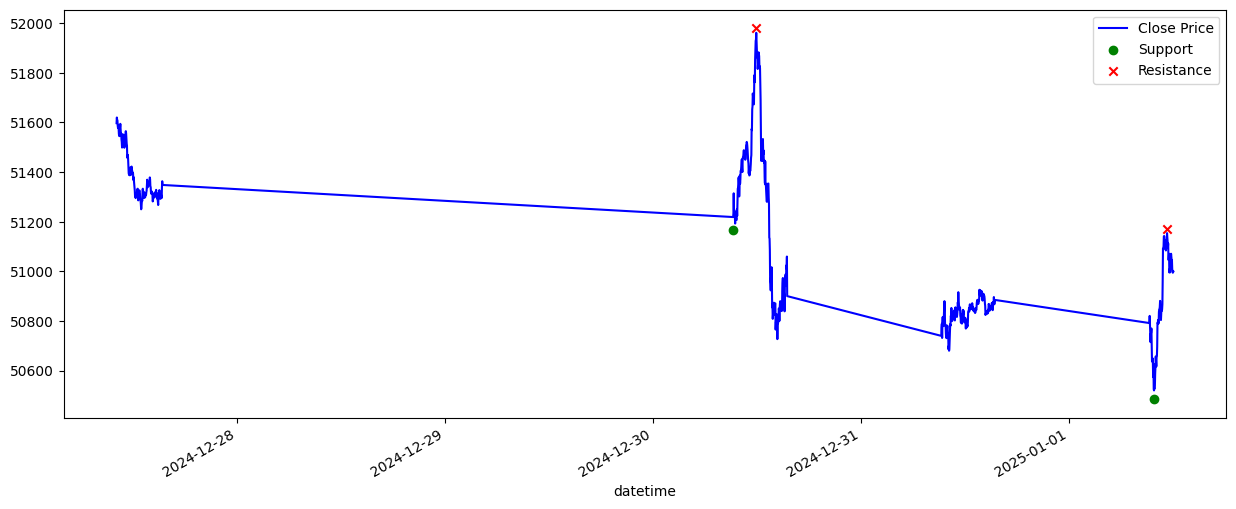

In [10]:
# Create a copy of the support and resistance columns to avoid modifying the original DataFrame
support_filtered = processed_df['support'].replace(0.0, float('nan'))
resistance_filtered = processed_df['resistance'].replace(0.0, float('nan'))

# Create a larger figure
plt.figure(figsize=(15, 6))

# Plot the close price
processed_df['close'].plot(label='Close Price', color='blue')

# Plot the support and resistance points, excluding 0/0.0 values
plt.scatter(processed_df.index, support_filtered, label='Support', color='green', marker='o')
plt.scatter(processed_df.index, resistance_filtered, label='Resistance', color='red', marker='x')

# Add legend and show plot
plt.legend()
plt.show()

In [11]:
class TradingEnvironment(gym.Env):
    def __init__(self, data, initial_capital=100000, quantity=25, brokerage=20):
        self.data = data.reset_index(drop=True)
        self.initial_capital = initial_capital
        self.quantity = quantity  # Directly set trade quantity
        self.brokerage = brokerage  # Brokerage per entry or exit
        self.current_step = 0

        # Trading stats
        self.total_trades = 0
        self.profitable_trades = 0
        self.total_pnl = 0
        self.win_rate = 0
        self.capital = initial_capital
        self.entry_price = None
        self.position = None  # 'buy' or 'sell'
        self.target_price = None
        self.sl_price = None
        self.entry_datetime = None  # To store entry datetime
        self.exit_datetime = None  # To store exit datetime

        # Observation and action space
        self.observation_space = spaces.Box(
            low=-np.inf, high=np.inf, shape=(data.shape[1],), dtype=np.float32
        )
        self.action_space = spaces.Discrete(4)  # 0: Hold, 1: Buy, 2: Sell, 3: Active Trade

    def reset(self):
        self.current_step = 0
        self.capital = self.initial_capital
        self.total_trades = 0
        self.profitable_trades = 0
        self.total_pnl = 0
        self.win_rate = 0
        self.entry_price = None
        self.position = None
        self.target_price = None
        self.sl_price = None
        self.entry_datetime = None  # Reset entry datetime
        self.exit_datetime = None  # Reset exit datetime
        return self._next_observation()

    def _next_observation(self):
        return self.data.iloc[self.current_step].values

    def step(self, action):
        done = False
        reward = 0

        current_close = self.data.iloc[self.current_step]["close"]
        target = self.data.iloc[self.current_step]["Target"]
        stop_loss = self.data.iloc[self.current_step]["Stop Loss"]
        current_datetime = self.data.index[self.current_step]  # Access the datetime index

        # If there's an active trade, restrict actions to only "3" (Active Trade)
        if self.position is not None:
            if action != 3:
                return self._next_observation(), 0, False, False, {
                    "capital": self.capital,
                    "total_trades": self.total_trades,
                    "profitable_trades": self.profitable_trades,
                    "win_rate": self.win_rate,
                    "total_pnl": self.total_pnl,
                }

            # Update target and stop-loss prices
            if self.position == "buy":
                self.target_price = self.entry_price + target
                self.sl_price = self.entry_price - stop_loss
            elif self.position == "sell":
                self.target_price = self.entry_price - target
                self.sl_price = self.entry_price + stop_loss

            # Check exit conditions
            if (self.position == "buy" and current_close >= self.target_price) or \
               (self.position == "sell" and current_close <= self.target_price):
                points_captured = abs(int(self.target_price - self.entry_price))  # Ensure points are integer
                pnl = points_captured * self.quantity - self.brokerage  # Deduct brokerage on exit
                self.capital += pnl
                self.total_pnl += pnl
                if pnl > 0:
                    self.profitable_trades += 1
                print(f"Exit: {self.position.capitalize()} at {current_close:.2f} on {current_datetime}, Target reached! Profit: ₹{pnl:,.2f}, Points captured: {points_captured}")
                self.position = None
                self.entry_price = None

            elif (self.position == "buy" and current_close <= self.sl_price) or \
                 (self.position == "sell" and current_close >= self.sl_price):
                points_lost = abs(int(self.sl_price - self.entry_price))  # Ensure points are integer
                pnl = -points_lost * self.quantity - self.brokerage  # Deduct brokerage on exit
                self.capital += pnl
                self.total_pnl += pnl
                print(f"Exit: {self.position.capitalize()} at {current_close:.2f} on {current_datetime}, Stop-loss hit! Loss: ₹{pnl:,.2f}, Points lost: {points_lost}")
                self.position = None
                self.entry_price = None

        else:  # No active trade
            if action == 1:  # Buy
                self.entry_price = current_close
                self.position = "buy"
                self.total_trades += 1
                self.capital -= self.brokerage  # Deduct brokerage on entry
                print(f"Entry: Buy at {current_close:.2f} on {current_datetime}")
            elif action == 2:  # Sell
                self.entry_price = current_close
                self.position = "sell"
                self.total_trades += 1
                self.capital -= self.brokerage  # Deduct brokerage on entry
                print(f"Entry: Sell at {current_close:.2f} on {current_datetime}")

        # Update win rate
        if self.total_trades > 0:
            self.win_rate = self.profitable_trades / self.total_trades

        self.current_step += 1
        if self.current_step >= len(self.data) - 1:
            done = True

        reward = self.total_pnl  # Reward is cumulative profit/loss
        return self._next_observation(), reward, done, False, {
            "capital": self.capital,
            "total_trades": self.total_trades,
            "profitable_trades": self.profitable_trades,
            "win_rate": self.win_rate,
            "total_pnl": self.total_pnl,
        }

In [12]:
class ReplayBuffer:
    def __init__(self, file_path="replay_buffer.pkl"):
        self.buffer = []
        self.file_path = file_path
        self._load()

    def add(self, observation, action, reward, next_observation, done):
        self.buffer.append((observation, action, reward, next_observation, done))

    def sample(self, batch_size):
        return random.sample(self.buffer, batch_size)

    def save(self):
        with open(self.file_path, "wb") as f:
            pickle.dump(self.buffer, f)

    def _load(self):
        try:
            with open(self.file_path, "rb") as f:
                self.buffer = pickle.load(f)
        except FileNotFoundError:
            self.buffer = []

In [13]:
# Policy Network
def create_policy_network(input_shape, action_space):
    model = tf.keras.Sequential([
        layers.InputLayer(shape=input_shape),
        layers.Dense(64, activation='relu'),
        layers.Dense(64, activation='relu'),
        layers.Dense(action_space, activation='softmax')  # Output probabilities for actions
    ])
    return model

# MAML Agent
class MAMLAgent:
    def __init__(self, env, learning_rate=0.01, meta_lr=0.001):
        self.env = env
        self.policy = create_policy_network(
            input_shape=env.observation_space.shape,
            action_space=env.action_space.n
        )
        self.optimizer = tf.keras.optimizers.Adam(learning_rate=meta_lr)
        self.inner_lr = learning_rate
        self.meta_batch_size = 4  # Number of tasks to sample per meta-update
        self.replay_buffer = ReplayBuffer()
        self.trade_log = []  # Track trade entries

    def inner_update(self, task_data):
        with tf.GradientTape() as tape:
            observations, actions, rewards = task_data
            logits = self.policy(observations)
            loss = self._compute_loss(logits, actions, rewards)
        grads = tape.gradient(loss, self.policy.trainable_variables)
        return grads

    def meta_update(self, meta_gradients):
        self.optimizer.apply_gradients(zip(meta_gradients, self.policy.trainable_variables))

    def _compute_loss(self, logits, actions, rewards):
        action_probs = tf.reduce_sum(actions * tf.nn.softmax(logits), axis=1)
        loss = -tf.reduce_mean(tf.math.log(action_probs) * rewards)
        return loss

    def train(self, num_iterations=100):
        capital_history = []
        for iteration in range(num_iterations):
            meta_gradients = [tf.zeros_like(var) for var in self.policy.trainable_variables]
            for _ in range(self.meta_batch_size):
                task_data = self._sample_task()
                grads = self.inner_update(task_data)
                meta_gradients = [
                    mg + g for mg, g in zip(meta_gradients, grads)
                ]
            self.meta_update(meta_gradients)

            # Collect metrics
            capital_history.append(self.env.capital)
            print(f"Iteration {iteration + 1}/{num_iterations} complete.")
            print(f"Capital: ₹{self.env.capital:,.2f}, Win Rate: {(self.env.profitable_trades / max(1, self.env.total_trades) * 100):.2f}%")

        return capital_history

    def _sample_task(self):
        obs, rewards, actions, next_obs, dones = [], [], [], [], []
        self.env.reset()
        done = False
        while not done:
            current_obs = self.env.data.iloc[self.env.current_step].values

            # Get valid actions based on the environment's state
            if self.env.position is not None:
                # Only action 3 is valid if there's an active trade
                valid_action = 3
            else:
                # If no active trade, allow actions 0 (Hold), 1 (Buy), or 2 (Sell)
                valid_action = np.random.choice([0, 1, 2])

            # Take the valid action
            action = valid_action
            obs.append(current_obs)
            actions.append(action)

            next_observation, reward, done, _, info = self.env.step(action)
            rewards.append(reward)
            next_obs.append(next_observation)
            dones.append(done)

            # Save to replay buffer
            self.replay_buffer.add(current_obs, action, reward, next_observation, done)

            # Log trades
            if action == 1:  # Buy
                self.trade_log.append({"step": self.env.current_step, "action": "buy", "price": self.env.data.iloc[self.env.current_step]["close"]})
            elif action == 2:  # Sell
                self.trade_log.append({"step": self.env.current_step, "action": "sell", "price": self.env.data.iloc[self.env.current_step]["close"]})

        return (
            tf.convert_to_tensor(np.array(obs), dtype=tf.float32),
            tf.convert_to_tensor(np.eye(self.env.action_space.n)[actions], dtype=tf.float32),
            tf.convert_to_tensor(np.array(rewards), dtype=tf.float32),
        )

In [14]:
def visualize_performance(capital_history, trade_log, df):
    # Scatter buy/sell entries on closing price
    plt.figure(figsize=(12, 6))
    plt.plot(range(len(df['close'])), df['close'], label='Close Price', color='black', alpha=0.5)

    buys = [log['step'] for log in trade_log if log['action'] == 'buy']
    sells = [log['step'] for log in trade_log if log['action'] == 'sell']

    # Ensure the indices for buys and sells are within bounds
    valid_buys = [b for b in buys if b < len(df['close'])]
    valid_sells = [s for s in sells if s < len(df['close'])]

    plt.scatter(valid_buys, df['close'].iloc[valid_buys], label='Buy', color='green', marker='^', alpha=0.7)
    plt.scatter(valid_sells, df['close'].iloc[valid_sells], label='Sell', color='red', marker='v', alpha=0.7)

    plt.title('Trade Entries on Closing Price')
    plt.xlabel('Index')
    plt.ylabel('Price')
    plt.legend()
    plt.show()

Entry: Sell at 51596.90 on 0
Exit: Sell at 51521.00 on 18, Target reached! Profit: ₹1,015.00, Points captured: 69
Entry: Sell at 51517.15 on 20
Exit: Sell at 51556.55 on 31, Stop-loss hit! Loss: ₹-500.00, Points lost: 32
Entry: Buy at 51534.95 on 34
Exit: Buy at 51457.35 on 37, Stop-loss hit! Loss: ₹-470.00, Points lost: 30
Entry: Sell at 51457.30 on 38
Exit: Sell at 51394.75 on 42, Target reached! Profit: ₹910.00, Points captured: 62
Entry: Sell at 51389.85 on 43
Exit: Sell at 51421.90 on 52, Stop-loss hit! Loss: ₹-425.00, Points lost: 27
Entry: Sell at 51409.35 on 53
Exit: Sell at 51354.70 on 61, Target reached! Profit: ₹730.00, Points captured: 50
Entry: Sell at 51340.45 on 62
Exit: Sell at 51285.75 on 75, Target reached! Profit: ₹715.00, Points captured: 49
Entry: Sell at 51294.10 on 76
Exit: Sell at 51326.05 on 79, Stop-loss hit! Loss: ₹-410.00, Points lost: 26
Entry: Sell at 51309.45 on 80
Exit: Sell at 51249.80 on 85, Target reached! Profit: ₹745.00, Points captured: 51
Entry: S

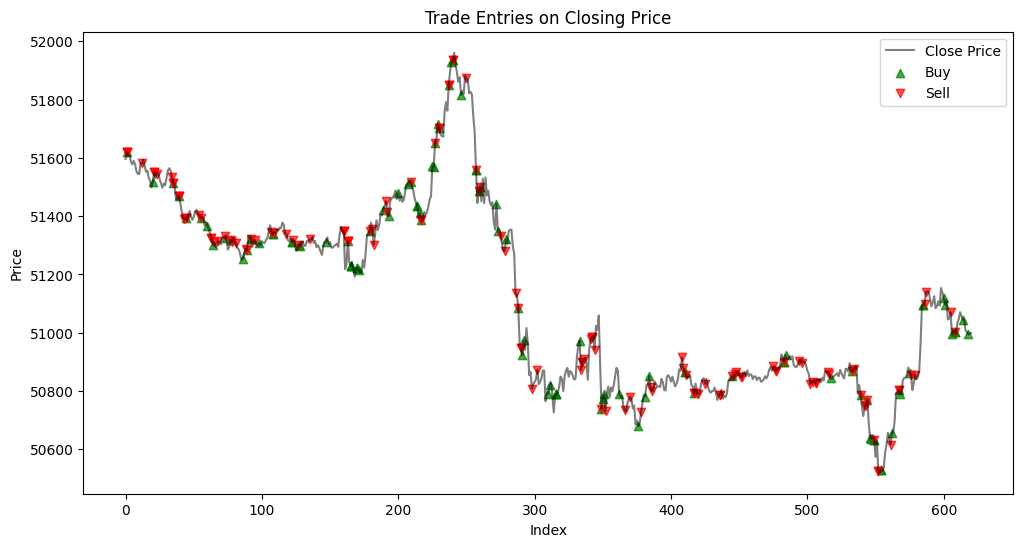

In [15]:
# Initialize environment and agent
env = TradingEnvironment(processed_df, quantity=quantity)
agent = MAMLAgent(env)

# Train agent
capital_history = agent.train(num_iterations=1)

# Save replay buffer
agent.replay_buffer.save()

# Visualize performance
visualize_performance(capital_history, agent.trade_log, processed_df)

In [17]:
class LiveTradingAgent:
    def __init__(self, maml_agent, live_env, replay_buffer):
        """
        Initialize the live trading agent with a trained MAML agent and a replay buffer.
        :param maml_agent: Trained MAML agent.
        :param live_env: Live trading environment.
        :param replay_buffer: Replay buffer for storing and reusing experiences.
        """
        self.agent = maml_agent
        self.env = live_env
        self.replay_buffer = replay_buffer

    def predict_action(self, observation):
        """
        Predict action for the latest data point.
        :param observation: The most recent data point (features).
        :return: Action (0: Hold, 1: Buy, 2: Sell).
        """
        observation = tf.convert_to_tensor(observation, dtype=tf.float32)
        observation = tf.expand_dims(observation, axis=0)  # Add batch dimension
        logits = self.agent.policy(observation)
        action = tf.argmax(logits, axis=1).numpy()[0]  # Choose the action with the highest probability
        return action

    def update_model(self, batch_size=32):
        """
        Perform gradient updates using a sampled batch from the replay buffer.
        :param batch_size: Number of samples to use for the update.
        """
        if len(self.replay_buffer.buffer) < batch_size:
            return  # Skip if not enough samples in the buffer

        # Sample a batch from the replay buffer
        batch = self.replay_buffer.sample(batch_size)
        observations, actions, rewards = [], [], []

        for obs, action, reward, _, _ in batch:
            observations.append(obs)
            actions.append(action)
            rewards.append(reward)

        observations = tf.convert_to_tensor(observations, dtype=tf.float32)
        actions_one_hot = tf.one_hot(actions, depth=self.env.action_space.n, dtype=tf.float32)
        rewards = tf.convert_to_tensor(rewards, dtype=tf.float32)

        with tf.GradientTape() as tape:
            logits = self.agent.policy(observations)
            loss = self.agent._compute_loss(logits, actions_one_hot, rewards)

        gradients = tape.gradient(loss, self.agent.policy.trainable_variables)
        self.agent.optimizer.apply_gradients(zip(gradients, self.agent.policy.trainable_variables))

    def run_live_trading(self, live_df):
        """
        Process the live data DataFrame for continuous predictions and updates.
        :param live_df: DataFrame containing live data (new rows added in real-time).
        """
        for index, row in live_df.iterrows():
            observation = row.values  # Features for the latest data point

            # Predict action
            action = self.predict_action(observation)

            # Print action
            action_str = "Buy" if action == 1 else "Sell" if action == 2 else "Hold"
            print(f"Action: {action_str}")

            # If action is Buy or Sell, ask for feedback
            reward = 0
            if action in [1, 2]:
                feedback = input(f"Enter feedback for {action_str} (profit/loss as numeric value): ")
                try:
                    reward = float(feedback)
                except ValueError:
                    print("Invalid feedback. Skipping update.")
                    continue

            # Store experience in replay buffer
            self.replay_buffer.add(observation, action, reward, None, False)

            # Save replay buffer to file after every experience
            self.replay_buffer.save()

            # Update the model using replay buffer
            self.update_model()

In [18]:
def get_sleep_time(interval_minutes, market_start_hour=9, market_start_minute=15):
    now = datetime.now(ist_timezone)
    market_start_time = now.replace(hour=market_start_hour, minute=market_start_minute, second=0, microsecond=0)

    if now < market_start_time:
        # If current time is before the market starts, set next_run_time to market start time
        next_run_time = market_start_time
    else:
        # Calculate the minutes since the market start time
        minutes_since_market_start = (now - market_start_time).total_seconds() // 60
        # Calculate the number of minutes to the next interval boundary
        minutes_to_next_interval = interval_minutes - (minutes_since_market_start % interval_minutes)
        # Calculate the next run time by adding these minutes to the current time
        next_run_time = (now + timedelta(minutes=minutes_to_next_interval)).replace(second=0, microsecond=0)

    # Calculate the sleep time in seconds
    sleep_time = (next_run_time - now).total_seconds()
    return sleep_time

In [19]:
#while True:
    # Fetch and process live data
    live_df = fetch_candle_data(100)  # Fetch last 100 candles
    live_data_processor = DataProcessor(live_df, peak_length=14, indicator_length=14)
    live_processed_df = live_data_processor.process().train_df

    # Load replay buffer
    live_replay_buffer = ReplayBuffer("replay_buffer.pkl")

    # Initialize environment and agent
    live_env = TradingEnvironment(live_processed_df)
    live_agent = LiveTradingAgent(agent, live_env, live_replay_buffer)

    # Get the latest data point
    latest_data = live_processed_df.iloc[-1]
    latest_features = latest_data.values

    # Predict action
    action = live_agent.predict_action(latest_features)
    action_str = "Buy" if action == 1 else "Sell" if action == 2 else "Hold"
    print(f"Predicted Action: {action_str}")

    # Skip further steps if action is Hold
    if action == 0:  # Hold
        sleep_time = get_sleep_time(interval_minutes)
        print(f"Sleeping for {sleep_time} seconds...")
        time.sleep(sleep_time)
        continue

    # Calculate Target and Stop-Loss
    close_price = latest_data["close"]
    target = latest_data["Target"]
    stop_loss = latest_data["Stop Loss"]
    target_price = close_price + target if action == 1 else close_price - target  # Target for Buy or Sell
    stop_loss_price = close_price - stop_loss if action == 1 else close_price + stop_loss  # SL for Buy or Sell

    # Monitor subsequent candles to evaluate the trade
    trade_outcome = None
    while trade_outcome is None:
        # Fetch new data
        live_df = fetch_candle_data(100)
        live_data_processor = DataProcessor(live_df, peak_length=14, indicator_length=14)
        live_processed_df = live_data_processor.process().train_df
        new_data = live_processed_df.iloc[-1]

        # Check if target or stop-loss is hit
        if action == 1:  # Buy
            if new_data["close"] >= target_price:
                trade_outcome = 1  # Profit
                print("Target hit for Buy action. Trade closed with profit.")
            elif new_data["close"] <= stop_loss_price:
                trade_outcome = -1  # Loss
                print("Stop-Loss hit for Buy action. Trade closed with loss.")
        elif action == 2:  # Sell
            if new_data["close"] <= target_price:
                trade_outcome = 1  # Profit
                print("Target hit for Sell action. Trade closed with profit.")
            elif new_data["close"] >= stop_loss_price:
                trade_outcome = -1  # Loss
                print("Stop-Loss hit for Sell action. Trade closed with loss.")

        # Sleep before the next refresh
        sleep_time = get_sleep_time(interval_minutes)
        print(f"Sleeping for {sleep_time} seconds...")
        time.sleep(sleep_time)

    # Update the model based on the trade outcome
    reward = trade_outcome * abs(target_price - close_price)  # Reward is profit/loss magnitude
    live_agent.update_model(latest_features, action, reward)

    # Add experience to replay buffer
    live_replay_buffer.add(latest_features, action, reward, None, False)
    live_replay_buffer.save()

Predicted Action: Hold
Sleeping for 99.575794 seconds...


KeyboardInterrupt: 